---   
# Mean Variance Frontier

- return: weighted average of assets in a basket 

- return: variance-covariance of assets' basket 

## data loading

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set()

In [ ]:
data = pd.read_csv("g:/python/data/pff/data_close.csv")
data.set_index('Date', inplace=True)
data = data.dropna()
ret = data.pct_change()
ret = ret.dropna()

In [ ]:
data.tail()

,MSFT,JPY=X,TSLA,^GSPC,AAPL,^XAU,GDX,INTC,GME,^VIX,GS,AMZN,GLD,SPY
Date,,,,,,,,,,,,,,
2021-02-24,234.550003,105.282997,742.020020,3925.429932,125.349998,143.350006,33.700001,63.189999,91.709999,21.340000,330.640015,3159.530029,169.000000,391.769989
2021-02-25,228.990005,105.944000,682.219971,3829.340088,120.989998,137.360001,32.330002,60.400002,108.730003,28.889999,327.760010,3057.159912,165.820007,382.329987
2021-02-26,232.380005,106.378998,675.500000,3811.149902,121.260002,130.789993,31.129999,60.779999,101.739998,27.950001,319.480011,3092.929932,161.809998,380.359985
2021-03-01,236.940002,106.502998,718.429993,3901.820068,127.790001,130.330002,30.900000,62.880001,120.400002,23.350000,329.920013,3146.139893,161.529999,389.579987
2021-03-02,233.869995,106.850998,686.440002,3870.290039,125.120003,134.843002,31.959999,61.240002,118.180000,24.100000,330.940002,3094.530029,162.410004,386.559998


In [2]:
import yfinance as yf 

tickers = ['AAPL', 'MSFT', 'GS', 'GLD']
df = pd.DataFrame()
for ticker in tickers:
    data = yf.download(ticker).Close
    df[str(ticker)] = data 

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
df = df.dropna()
ret = df.pct_change() 
ret = ret.dropna()

In [ ]:
# assets = ['AAPL', 'MSFT', 'GS', 'GLD']  # Apple, Microsoft, Goldman Sachs, Gold-etf
# data = data[assets]
# ret =ret[assets]
# noa = len(assets)

In [8]:
# time series plot 
plt.figure(figsize=(15,7))
df.plot(backend='plotly')

<Figure size 1080x504 with 0 Axes>

<AxesSubplot:xlabel='Date'>

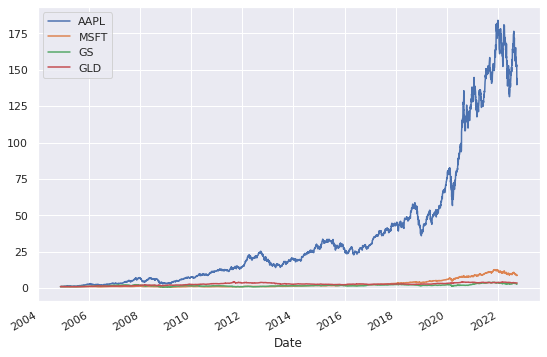

In [9]:
 # normalized time series plot to compare return relatively
 df_norm = df / df.iloc[0, :]
 df_norm.plot(figsize=(9,6))

# Construct mean variance frontier 

In [10]:
noa = 4

def get_mvf(noa, rf=0):
    port_ret = []
    port_std = []
    port_sr = []

    for i in range(10000):
        weight = np.random.rand(4)
        weight /= weight.sum()
        mu, sigma, sr = get_moments(weight, ret)
        port_ret.append(mu)
        port_std.append(sigma)
        port_sr.append(sr)

    return pd.DataFrame().assign(ret=port_ret, sigma=port_std, sr=port_sr)    


def get_moments(weights, ret, rf=0):
    mu = np.sum(weights * ret.mean()) * 250  # annulaized 
    var = ret.cov() * 250
    sigma = np.sqrt(np.dot(weights.T, np.dot(var, weights)))
    sr = (mu - rf) / sigma
    return mu, sigma, sr 


In [11]:
data = get_mvf(noa)

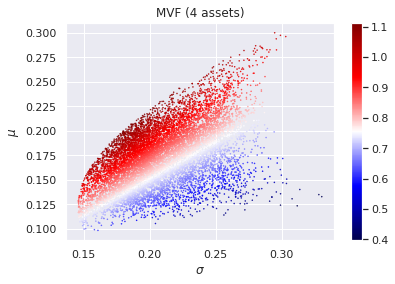

In [13]:
plt.scatter(data.sigma, data.ret, s=1, marker=".", c=data.sr, cmap='seismic')
plt.colorbar()
plt.xlabel('$\sigma$')
plt.ylabel('$\mu$')
plt.title("MVF (4 assets)"); 

# Portfolio allocation with maximizing Sharpe-ratio

### Optimization: weights maximizing the Sharpe ratio
$$
\begin{align*}
max_{w_i's} (sr)\equiv \frac{r_p-r_f}{\sigma_p} \\
~~& s.t   \sum w_i =1 , 0 \le w_i \le 1
\end{align*}
$$

In [16]:
import scipy.optimize as opt 

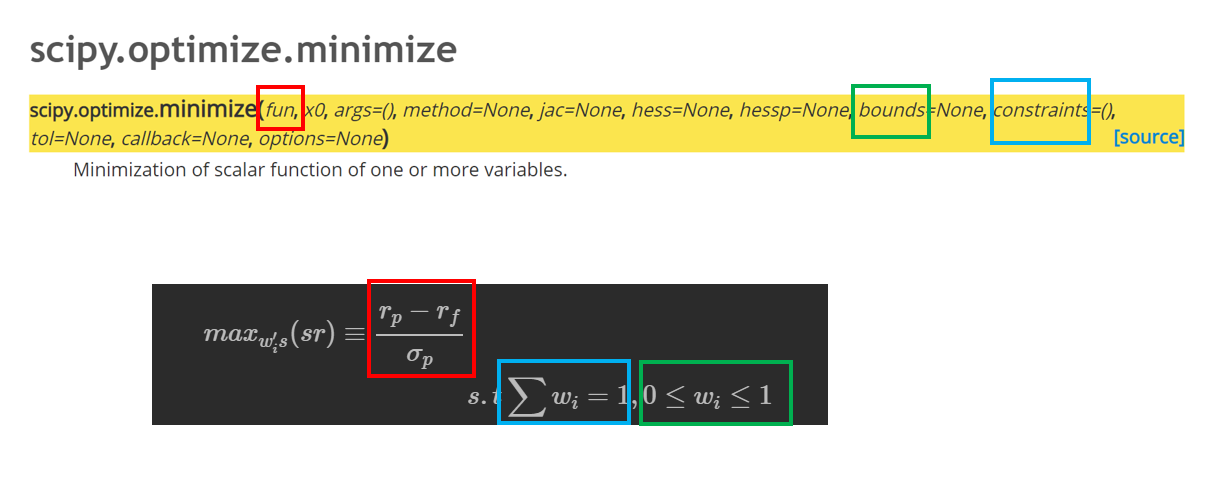

In [ ]:
from IPython.display import Image 
Image("G:/python/images/scipy_opt.PNG")

In [14]:
def sr_opt_fun(weight):
    weight = np.array(weight)
    p_ret = np.sum(ret.mean() * weight) * 250
    p_sigma = np.sqrt(np.dot(weight.T, np.dot(ret.cov() * 250, weight)))
    
    return np.array(p_ret/p_sigma) * (-1)    

In [17]:
constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) -1}]   # sum(weights)=1
bounds = tuple((0,1) for x in range(noa))

opts_sharp = opt.minimize(sr_opt_fun, noa * [1. / noa], method='SLSQP', bounds=bounds, constraints=constraints)

In [18]:
result_sharp = pd.DataFrame().assign(weights =opts_sharp.x.round(3)).set_index(ret.columns)

In [19]:
result_sharp

,weights
AAPL,0.494
MSFT,0.046
GS,0.000
GLD,0.460


In [20]:
# Sharpe ratio maximization' (return, sigma, sr)

list(map(lambda x : x.round(3), get_moments(result_sharp.weights, ret)))

[0.211, 0.189, 1.115]

# Asset allocation with minimizing volatility

\begin{align*}
\min_{w_i's} \sigma_p^2 \\
~~& s.t   \sum w_i =1 , 0 \le w_i \le 1
\end{align*}

In [21]:
import scipy.optimize as opt 

In [22]:
def volatility_opt_fun(weight):
    weight = np.array(weight)
    p_ret = np.sum(ret.mean() * weight) * 250
    p_sigma = np.sqrt(np.dot(weight.T, np.dot(ret.cov() * 250, weight)))
    
    return np.array(p_sigma **2)

In [23]:
constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) -1}]   # sum(weights)=1
bounds = tuple((0,1) for x in range(noa))

opts_vol = opt.minimize(volatility_opt_fun, noa * [1. / noa], method='SLSQP', bounds=bounds, constraints=constraints)

In [24]:
result_vol = pd.DataFrame().assign(weights =opts_vol.x.round(3)).set_index(ret.columns)
result_vol

,weights
AAPL,0.078
MSFT,0.190
GS,0.068
GLD,0.664


In [25]:
# Volatility minimization' (return, sigma, sr)

list(map(lambda x : x.round(3), get_moments(result_vol.weights, ret)))

[0.122, 0.146, 0.836]

## Asset allocation with minimizing volatility and with target return 

\begin{align*}
\min_{w_i's} \sigma_p^2 \\
~~& s.t   \sum w_i =1 ,\;\;\; 0 \le w_i \le 1, \;\;\;  r_p = \bar{r}
\end{align*}

In [ ]:
import scipy.optimize as opt 
import numpy as np 

In [27]:
def volatility_opt_fn(weight):
    weight = np.array(weight)
    p_ret = np.sum(ret.mean() * weight) * 250
    p_sigma = np.sqrt(np.dot(weight.T, np.dot(ret.cov() * 250, weight)))
    
    return np.array(p_sigma **2)


def get_return(weight):
    mu = np.sum(weight * ret.mean()) * 250  # annulaized 
    return mu

## Optimal portfolio frontier

In [28]:
trgts = np.linspace(0.0, 0.25, 50)
trgt_vol = []

for trgt in trgts: 
    constraints = [{"type": 'eq', 'fun': lambda x: sum(x) -1}, 
                   {"type": 'eq', 'fun': lambda x: get_return(x) - trgt}]
    bounds = tuple((0, 1) for x in range(noa))
    opt_vol = opt.minimize(volatility_opt_fn, noa * [1./noa],  method='SLSQP',
                           constraints=constraints, bounds=bounds)
    trgt_vol.append(opt_vol['fun'])                       


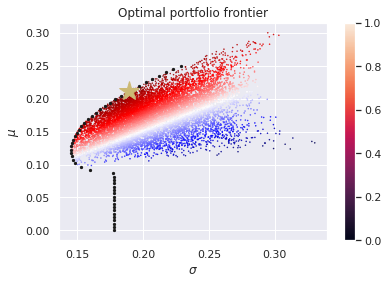

In [30]:
sharp_result = list(map(lambda x : x.round(3), get_moments(result_sharp.weights, ret)))


plt.scatter(data.sigma, data.ret, s=1, marker=".", c=data.sr, cmap='seismic')
plt.scatter(np.sqrt(trgt_vol), trgts, s=5, c='k')
plt.plot(sharp_result[1], sharp_result[0], 'y*', markersize=20)
plt.colorbar()
plt.xlabel('$\sigma$')
plt.ylabel('$\mu$')
plt.title("Optimal portfolio frontier"); 